# Online Food Delivery — Customer Ordering Behavior

**Business question:** Which demographic, income, and household factors are associated with whether a customer places an online food order, and how satisfied are the customers who do?

Dataset: [Online Food Ordering Dataset (Kaggle)](https://www.kaggle.com/datasets/srisyra02/online-food-ordering-dataset) — 388 survey responses from customers of an online food delivery service in Bangalore, India.

The CSV is included directly in `data/`, so this notebook runs as-is — no download needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('data/onlinefoods.csv')
df.shape

(388, 14)

## 1. Clean the data

In [2]:
# The raw CSV has an unnamed 14th column that exactly duplicates `Output` — drop it.
assert (df['Unnamed: 13'] == df['Output']).all()
df = df.drop(columns=['Unnamed: 13'])

# Feedback has trailing whitespace on some values (e.g. "Negative ")
df['Feedback'] = df['Feedback'].str.strip()

print('Missing values:', df.isna().sum().sum())
print('Exact duplicate rows:', df.duplicated().sum(), f"({df.duplicated().mean():.1%} of all rows)")

# This is a small survey dataset with a limited set of possible answer combinations,
# so duplicate rows are plausible real respondents, not a guaranteed data error —
# analysis below uses the full 388 rows, but this is worth flagging for anyone modeling the data.
df.head(3)

Missing values: 0
Exact duplicate rows: 103 (26.5% of all rows)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative


## 2. Who places an order, and how do they feel about it?

`Output` (Yes/No) marks whether the respondent's most recent interaction ended in an order; `Feedback` is their sentiment about the service.

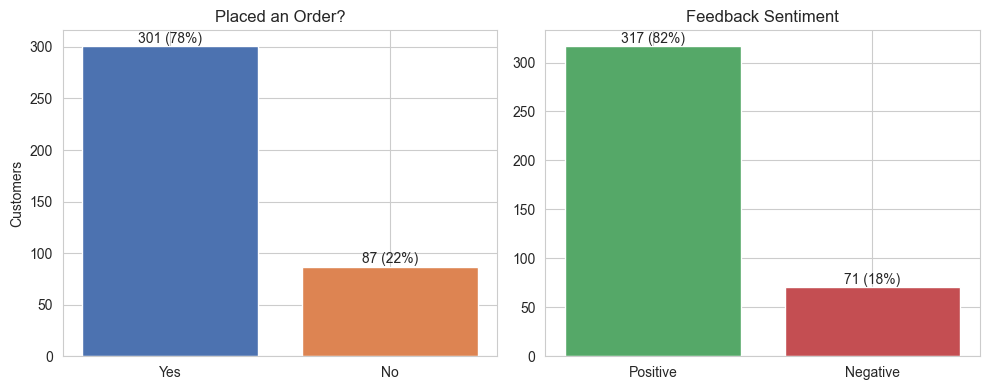

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

order_counts = df['Output'].value_counts()
axes[0].bar(order_counts.index, order_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Placed an Order?')
axes[0].set_ylabel('Customers')
for i, v in enumerate(order_counts.values):
    axes[0].text(i, v + 3, f'{v} ({v/len(df):.0%})', ha='center')

feedback_counts = df['Feedback'].value_counts()
axes[1].bar(feedback_counts.index, feedback_counts.values, color=['#55A868', '#C44E52'])
axes[1].set_title('Feedback Sentiment')
for i, v in enumerate(feedback_counts.values):
    axes[1].text(i, v + 3, f'{v} ({v/len(df):.0%})', ha='center')

plt.tight_layout()
plt.savefig('images/01_output_feedback_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Order rate by occupation

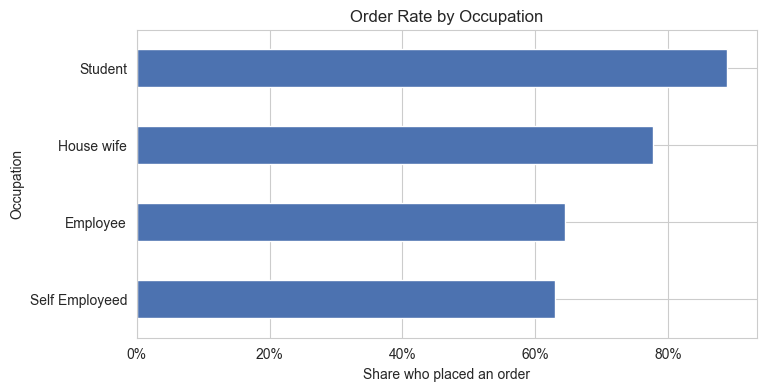

Occupation
Student           207
Employee          118
Self Employeed     54
House wife          9
Name: count, dtype: int64

In [4]:
order_by_occupation = pd.crosstab(df['Occupation'], df['Output'], normalize='index')['Yes'].sort_values()

plt.figure(figsize=(8, 4))
order_by_occupation.plot(kind='barh', color='#4C72B0')
plt.xlabel('Share who placed an order')
plt.title('Order Rate by Occupation')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.savefig('images/02_order_rate_by_occupation.png', bbox_inches='tight', dpi=150)
plt.show()

df['Occupation'].value_counts()

## 4. Order rate by monthly income

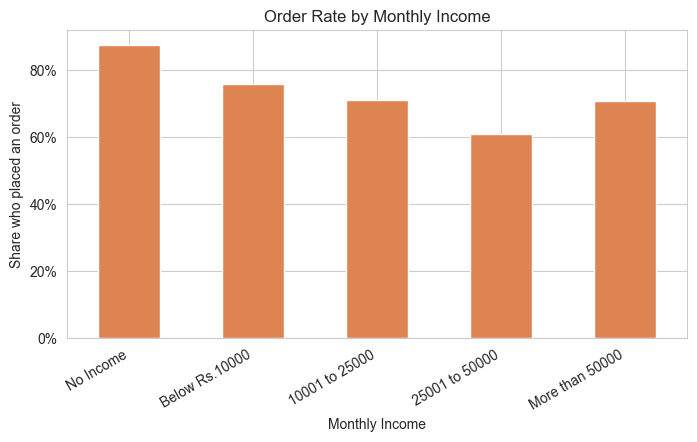

In [5]:
income_order = ['No Income', 'Below Rs.10000', '10001 to 25000', '25001 to 50000', 'More than 50000']
order_by_income = pd.crosstab(df['Monthly Income'], df['Output'], normalize='index')['Yes'].reindex(income_order)

plt.figure(figsize=(8, 4))
order_by_income.plot(kind='bar', color='#DD8452')
plt.ylabel('Share who placed an order')
plt.title('Order Rate by Monthly Income')
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.savefig('images/03_order_rate_by_income.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Order rate by marital status and customer type

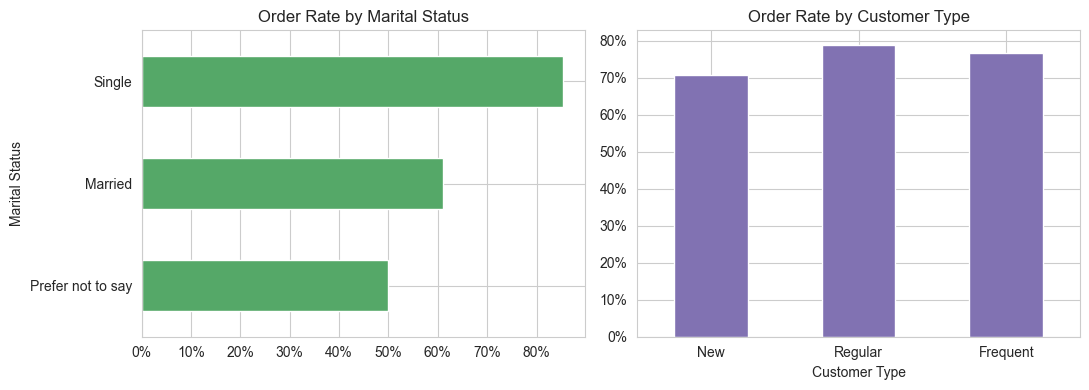

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order_by_marital = pd.crosstab(df['Marital Status'], df['Output'], normalize='index')['Yes'].sort_values()
order_by_marital.plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title('Order Rate by Marital Status')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

type_order = ['New', 'Regular', 'Frequent']
order_by_type = pd.crosstab(df['Customer Type'], df['Output'], normalize='index')['Yes'].reindex(type_order)
order_by_type.plot(kind='bar', ax=axes[1], color='#8172B2')
axes[1].set_title('Order Rate by Customer Type')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[1].set_xticklabels(type_order, rotation=0)

plt.tight_layout()
plt.savefig('images/04_order_rate_by_marital_customer_type.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Age and family size vs. ordering behavior

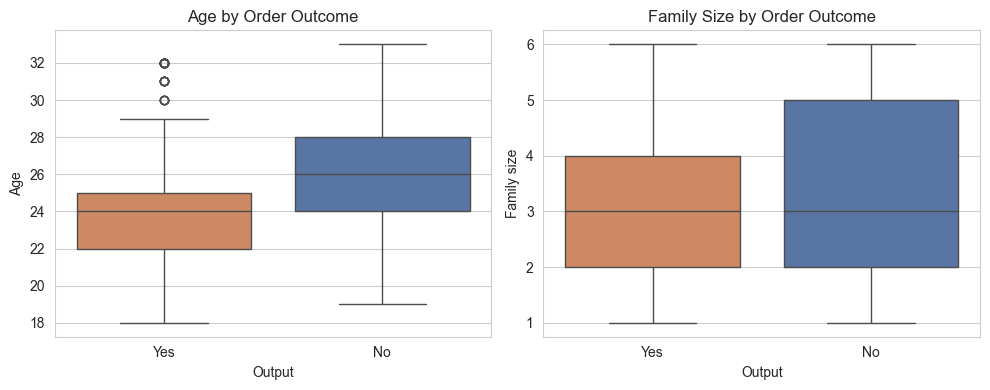

,Age,Family size
Output,,
No,26.00,3.39
Yes,24.23,3.25


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, x='Output', y='Age', hue='Output', palette=['#DD8452', '#4C72B0'], legend=False, ax=axes[0])
axes[0].set_title('Age by Order Outcome')

sns.boxplot(data=df, x='Output', y='Family size', hue='Output', palette=['#DD8452', '#4C72B0'], legend=False, ax=axes[1])
axes[1].set_title('Family Size by Order Outcome')

plt.tight_layout()
plt.savefig('images/05_age_familysize_by_output.png', bbox_inches='tight', dpi=150)
plt.show()

df.groupby('Output')[['Age', 'Family size']].mean().round(2)

## 7. Key findings & recommendations

**Findings:**
- **77.6%** of respondents placed an order; **81.7%** of respondents gave positive feedback — the service converts and satisfies most of the people it reaches.
- **Students order at the highest rate (88.9%)**, ahead of house wives (77.8%), employees (64.4%), and the self-employed (63.0%) — despite students being the largest income-poor group (187 of 388 respondents report "No Income").
- Counterintuitively, **the "No Income" bracket has the highest order rate of any income group (87.7%)**, while "25001 to 50000" earners have the lowest (60.9%). This lines up with occupation: "No Income" is overwhelmingly students, who order the most — income bracket alone is a weak, and sometimes misleading, predictor of ordering here without accounting for occupation and life stage.
- **Single respondents order at 85.4% vs. 61.1% for married respondents** — single/student status, not raw income, looks like the stronger driver of order likelihood in this sample.
- **Customer type tracks order rate as expected**: Frequent (76.7%) and Regular (78.9%) customers order at similar, higher rates than New customers (70.8%), consistent with New customers still being early in the relationship.
- Customers who did **not** order skew slightly **older** (mean age 26.0 vs. 24.2) and report a slightly **larger** family size (3.39 vs. 3.25) than those who did — small gaps, not strong effects, in this sample.
- **Data quality note:** 103 of 388 rows (26.5%) are exact duplicates. For a short categorical survey this is plausible (limited possible answer combinations), but it should be flagged before this data is used to train a predictive model, since duplicates can inflate confidence in patterns that are really driven by a handful of unique respondents.

**Recommendations:**
1. Prioritize acquisition and retention efforts on **students and single, no/low-income young adults** — the segment already converting and responding most positively — rather than assuming higher income brackets are the best-fit customer.
2. Investigate **why mid-income earners (₹25k–50k) convert least (60.9%)** — this is the one segment where price, competing options, or product-market fit may need attention.
3. Treat **New customers (70.8% order rate, only 24 respondents)** as the group needing the most onboarding support to reach Regular/Frequent conversion rates.
4. Before building a predictive model on this dataset, **de-duplicate rows** and validate that the "No Income" → high order-rate relationship isn't purely a proxy for the Student occupation group.

Full code and outputs are in this notebook.